# Netflix User Churn Prediction 
## Dataset: Netflix User Behavior Dataset
### Target: Predict whether a user will churn (Yes/No)
---
**Pipeline includes:**
- Exploratory Data Analysis (Univariate, Bivariate, Multivariate)
- Data Preprocessing & Feature Engineering
- Model Training (Random Forest Classifier)
- Hyperparameter Tuning (GridSearchCV)
- Model Evaluation

# Task 1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn libraries
from sklearn.model_selection import train_test_split,GridSearchCV,cross_val_score
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

# Task 2: Load the Dataset

In [2]:
df=pd.read_csv("C:\\Users\\User\\Downloads\\netflix\\netflix_user_behavior_dataset.csv")
print('Shape:', df.shape)

Shape: (50000, 20)


In [3]:
df.head()

,user_id,age,gender,country,account_age_months,subscription_type,monthly_fee,payment_method,primary_device,devices_used,favorite_genre,avg_watch_time_minutes,watch_sessions_per_week,binge_watch_sessions,completion_rate,rating_given,content_interactions,recommendation_click_rate,days_since_last_login,churned
0,U100000,56,Male,India,17,Standard,15.99,PayPal,Laptop,1,Sci-Fi,220,17,3,60,1.7,5,66,16,No
1,U100001,46,Female,USA,20,Standard,12.99,PayPal,Tablet,2,Documentary,76,15,4,71,4.6,7,78,14,No
2,U100002,32,Other,USA,25,Basic,15.99,PayPal,Tablet,2,Comedy,215,6,13,33,2.0,27,29,41,No
3,U100003,60,Male,Canada,37,Standard,12.99,PayPal,Smart TV,3,Action,280,4,9,58,1.2,9,23,22,No
4,U100004,25,Male,Brazil,23,Premium,12.99,PayPal,Mobile,3,Horror,261,15,9,64,1.3,49,56,54,No


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   user_id                    50000 non-null  object 
 1   age                        50000 non-null  int64  
 2   gender                     50000 non-null  object 
 3   country                    50000 non-null  object 
 4   account_age_months         50000 non-null  int64  
 5   subscription_type          50000 non-null  object 
 6   monthly_fee                50000 non-null  float64
 7   payment_method             50000 non-null  object 
 8   primary_device             50000 non-null  object 
 9   devices_used               50000 non-null  int64  
 10  favorite_genre             50000 non-null  object 
 11  avg_watch_time_minutes     50000 non-null  int64  
 12  watch_sessions_per_week    50000 non-null  int64  
 13  binge_watch_sessions       50000 non-null  int

In [5]:
df.describe()

,age,account_age_months,monthly_fee,devices_used,avg_watch_time_minutes,watch_sessions_per_week,binge_watch_sessions,completion_rate,rating_given,content_interactions,recommendation_click_rate,days_since_last_login
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,40.979240,29.874000,12.323340,1.999140,154.946520,9.986920,7.002520,64.533420,3.002316,24.306380,49.563000,29.410520
std,13.528733,17.051104,3.309109,0.818238,83.727292,5.480616,4.335819,20.206377,1.152308,14.468037,28.816997,17.312414
min,18.000000,1.000000,7.990000,1.000000,10.000000,1.000000,0.000000,30.000000,1.000000,0.000000,0.000000,0.000000
25%,29.000000,15.000000,7.990000,1.000000,83.000000,5.000000,3.000000,47.000000,2.000000,12.000000,25.000000,14.000000
50%,41.000000,30.000000,12.990000,2.000000,155.000000,10.000000,7.000000,65.000000,3.000000,24.000000,50.000000,29.000000
75%,53.000000,45.000000,15.990000,3.000000,228.000000,15.000000,11.000000,82.000000,4.000000,37.000000,75.000000,44.000000
max,64.000000,59.000000,15.990000,3.000000,299.000000,19.000000,14.000000,99.000000,5.000000,49.000000,99.000000,59.000000


In [6]:
df.isnull().sum()

user_id                      0
age                          0
gender                       0
country                      0
account_age_months           0
subscription_type            0
monthly_fee                  0
payment_method               0
primary_device               0
devices_used                 0
favorite_genre               0
avg_watch_time_minutes       0
watch_sessions_per_week      0
binge_watch_sessions         0
completion_rate              0
rating_given                 0
content_interactions         0
recommendation_click_rate    0
days_since_last_login        0
churned                      0
dtype: int64

# Task 3: Exploratory Data Analysis (EDA)
## 3a: Univariate Analysis
### Analyzing each column individually

In [7]:
# Target Variable Distribution
print('Churned Value Counts:')
print(df['churned'].value_counts())
print('\nPercentage:')
print(df['churned'].value_counts(normalize=True) * 100)

Churned Value Counts:
churned
No     40036
Yes     9964
Name: count, dtype: int64

Percentage:
churned
No     80.072
Yes    19.928
Name: proportion, dtype: float64


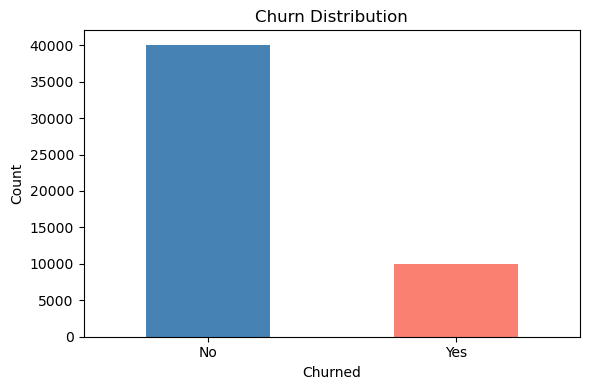

In [8]:
# Target variable bar plot
plt.figure(figsize=(6,4))
df['churned'].value_counts().plot(kind='bar', color=['steelblue','salmon'])
plt.title('Churn Distribution')
plt.xlabel('Churned')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

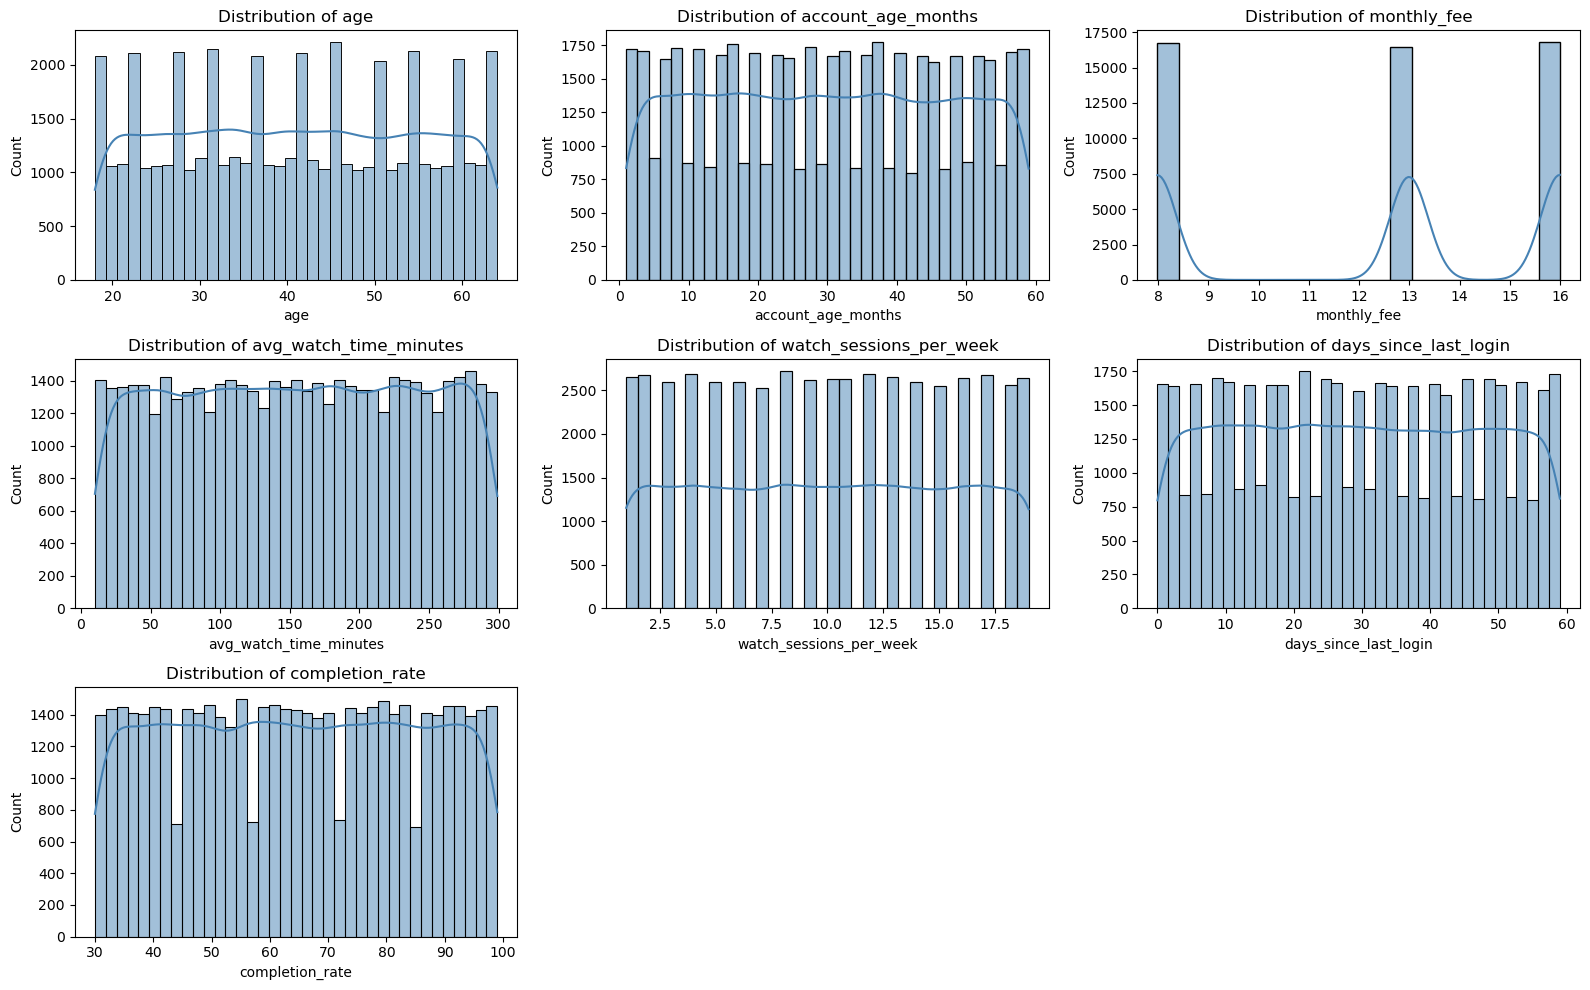

In [11]:
# Distribution of numerical columns
num_cols=['age','account_age_months','monthly_fee','avg_watch_time_minutes','watch_sessions_per_week','days_since_last_login','completion_rate']

plt.figure(figsize=(16,10))
for i,col in enumerate(num_cols,1):
    plt.subplot(3,3,i)
    sns.histplot(df[col], kde=True,color='steelblue')
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
plt.show()

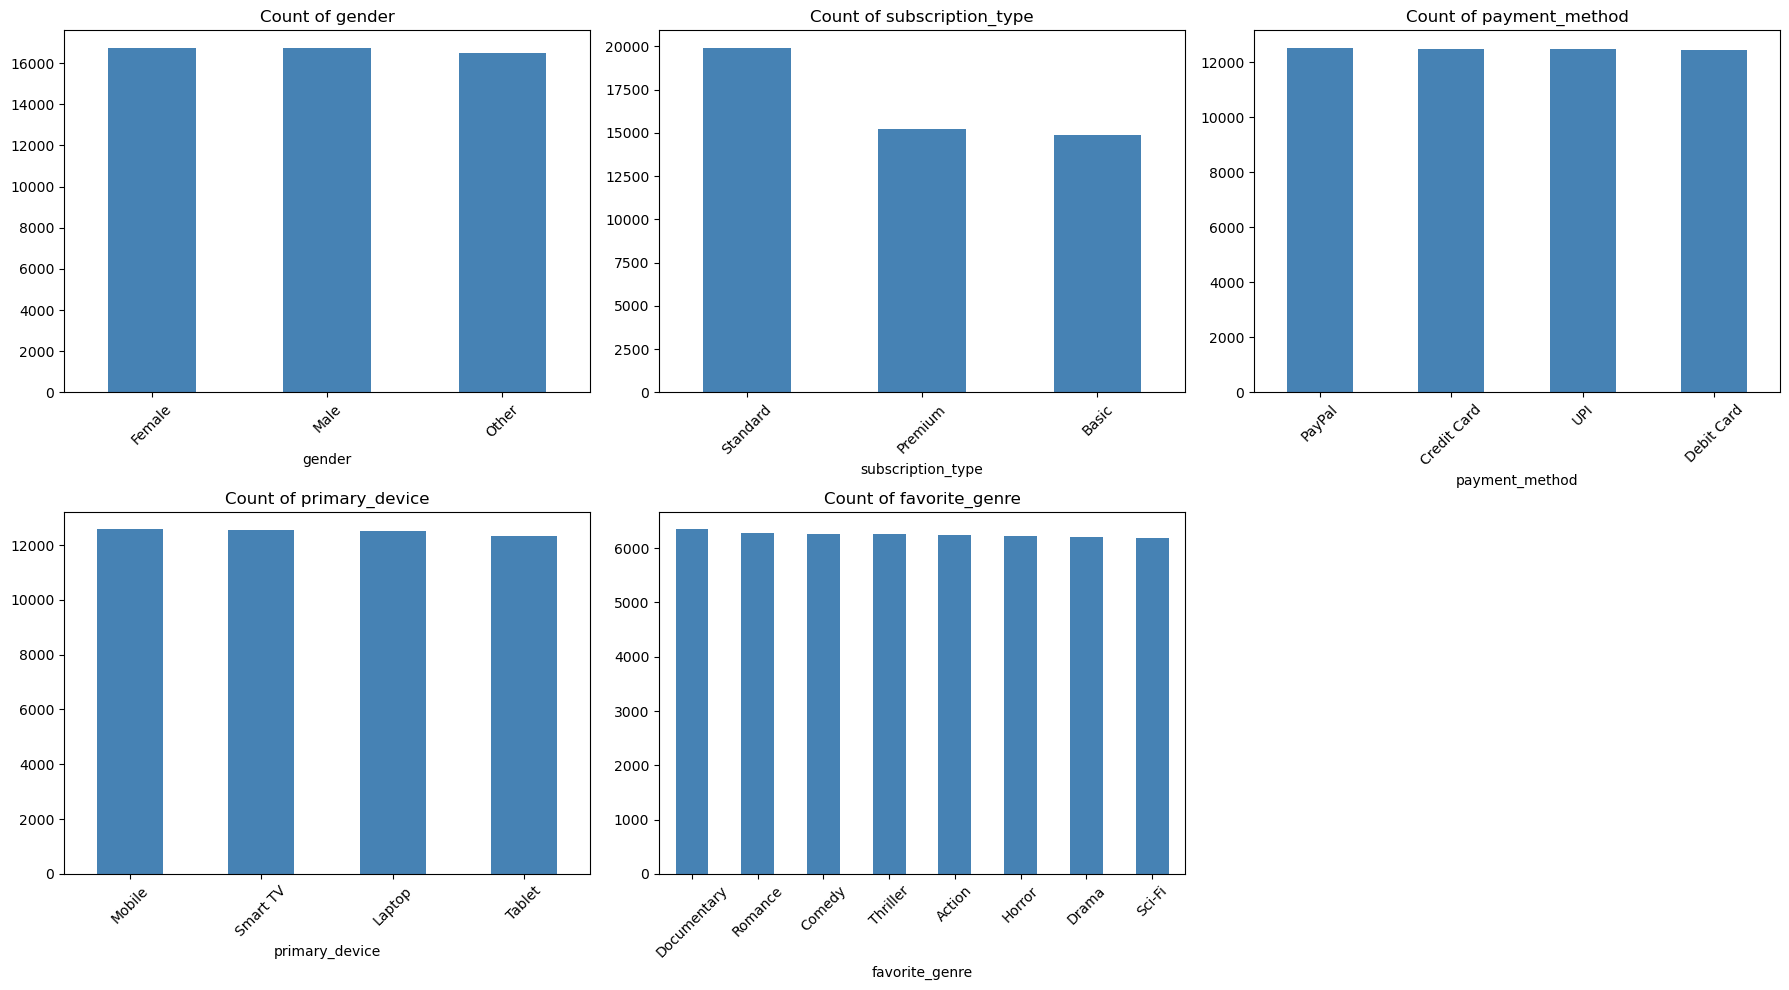

In [12]:
# Categorical columns - Count plots
cat_cols=['gender','subscription_type','payment_method','primary_device','favorite_genre']

plt.figure(figsize=(18,10))
for i,col in enumerate(cat_cols,1):
    plt.subplot(2,3,i)
    df[col].value_counts().plot(kind='bar',color='steelblue')
    plt.title(f'Count of {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
plt.show()

## 3b: Bivariate Analysis
### Analyzing relationship between two variables

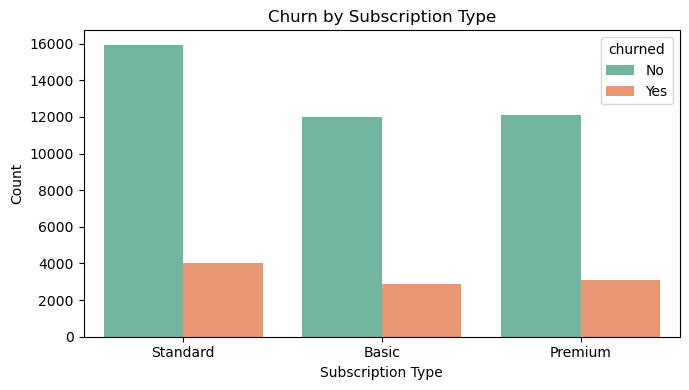

In [13]:
# Churn vs Subscription Type
plt.figure(figsize=(7,4))
sns.countplot(data=df,x='subscription_type',hue='churned',palette='Set2')
plt.title('Churn by Subscription Type')
plt.xlabel('Subscription Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

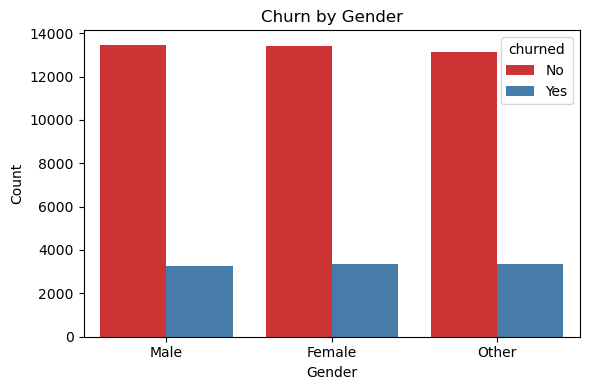

In [14]:
# Churn vs Gender
plt.figure(figsize=(6,4))
sns.countplot(data=df,x='gender',hue='churned',palette='Set1')
plt.title('Churn by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

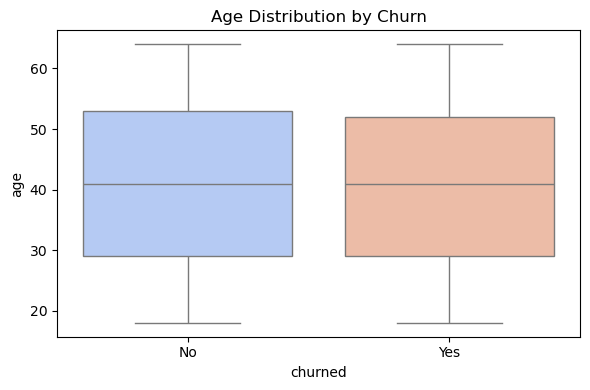

In [15]:
# Age vs Churned (Boxplot)
plt.figure(figsize=(6,4))
sns.boxplot(data=df,x='churned',y='age',palette='coolwarm')
plt.title('Age Distribution by Churn')
plt.tight_layout()
plt.show()

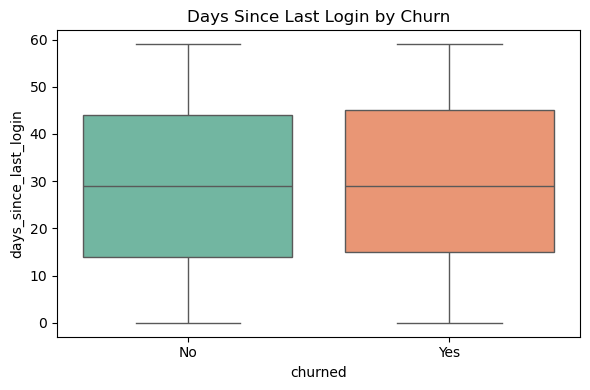

In [16]:
# Days Since Last Login vs Churned
plt.figure(figsize=(6,4))
sns.boxplot(data=df,x='churned',y='days_since_last_login',palette='Set2')
plt.title('Days Since Last Login by Churn')
plt.tight_layout()
plt.show()

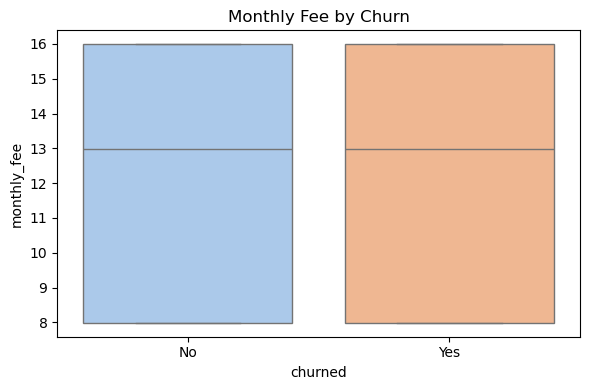

In [17]:
# Monthly Fee vs Churned
plt.figure(figsize=(6,4))
sns.boxplot(data=df,x='churned',y='monthly_fee',palette='pastel')
plt.title('Monthly Fee by Churn')
plt.tight_layout()
plt.show()

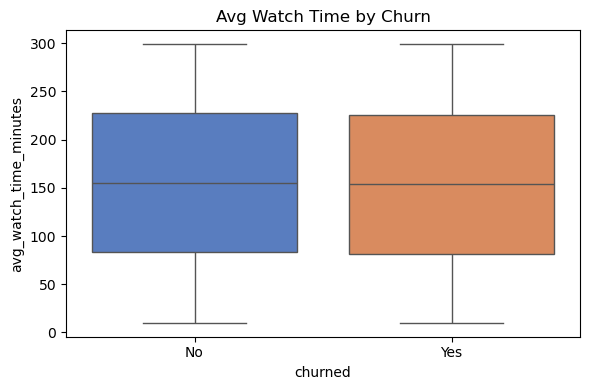

In [18]:
# Average Watch Time vs Churned
plt.figure(figsize=(6,4))
sns.boxplot(data=df,x='churned',y='avg_watch_time_minutes',palette='muted')
plt.title('Avg Watch Time by Churn')
plt.tight_layout()
plt.show()

## 3c: Multivariate Analysis
### Analyzing relationships between multiple variables

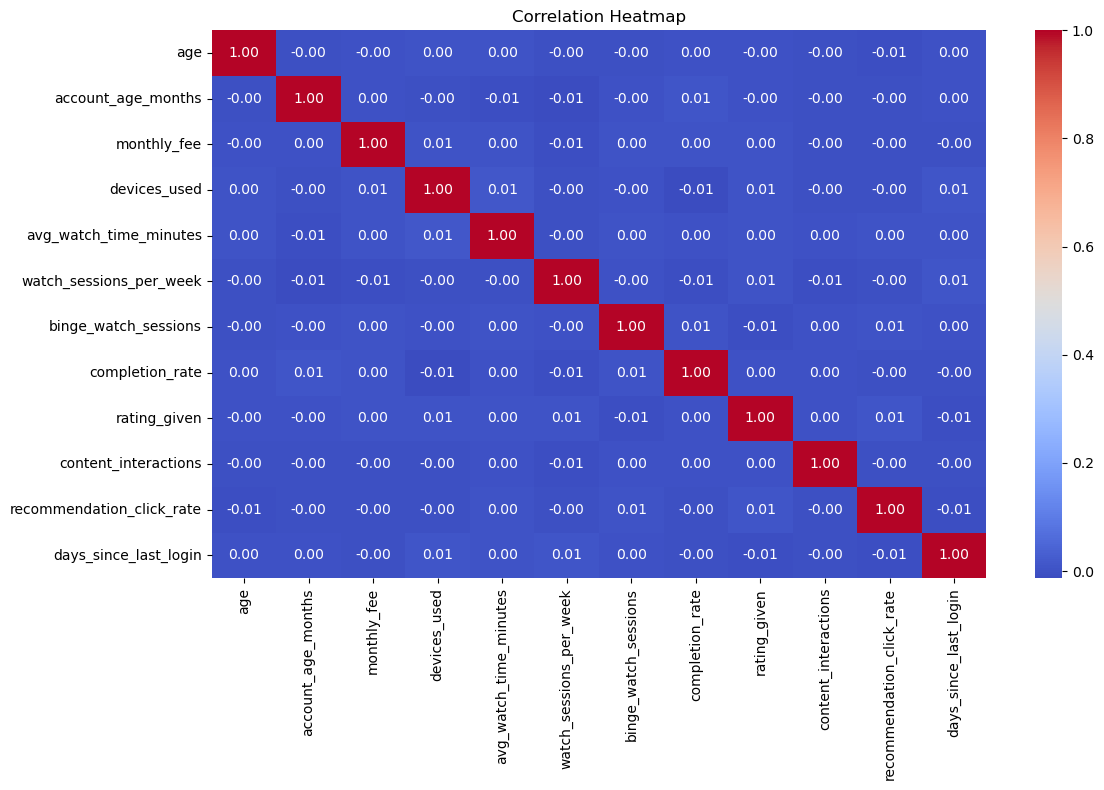

In [19]:
# Correlation Heatmap (Numerical Columns)
num_cols_all=['age','account_age_months','monthly_fee','devices_used','avg_watch_time_minutes','watch_sessions_per_week','binge_watch_sessions',
                'completion_rate','rating_given','content_interactions','recommendation_click_rate','days_since_last_login']

plt.figure(figsize=(12,8))
sns.heatmap(df[num_cols_all].corr(),annot=True,fmt='.2f',cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

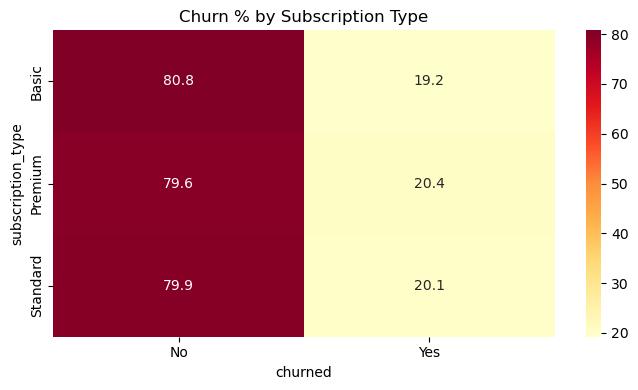

In [21]:
# Subscription Type + Gender + Churn
ct=pd.crosstab(df['subscription_type'],df['churned'])
ct_pct=ct.div(ct.sum(axis=1), axis=0)*100

plt.figure(figsize=(7,4))
sns.heatmap(ct_pct,annot=True,fmt='.1f',cmap='YlOrRd')
plt.title('Churn % by Subscription Type')
plt.tight_layout()
plt.show()

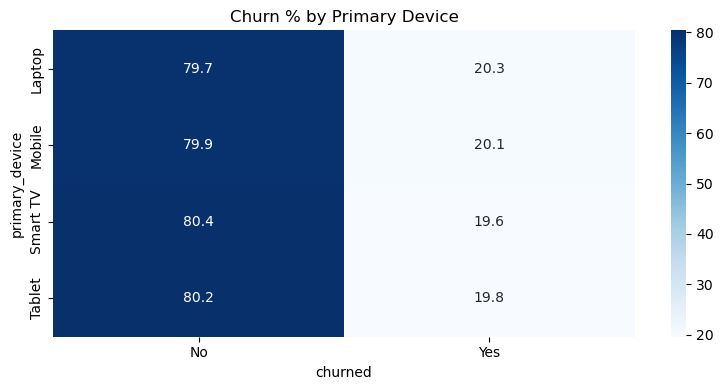

In [22]:
# Churn % by Primary Device
ct2=pd.crosstab(df['primary_device'],df['churned'])
ct2_pct=ct2.div(ct2.sum(axis=1), axis=0)*100

plt.figure(figsize=(8,4))
sns.heatmap(ct2_pct,annot=True,fmt='.1f',cmap='Blues')
plt.title('Churn % by Primary Device')
plt.tight_layout()
plt.show()

# Task 4: Data Preprocessing
## Drop unnecessary columns and encode categorical variables

In [8]:
# Droping user_id 
df=df.drop('user_id',axis=1)

In [9]:
# Encode all categorical columns using LabelEncoder
le=LabelEncoder()
cat_cols=df.select_dtypes(include='object').columns.tolist()
print('Categorical columns to encode:',cat_cols)

for col in cat_cols:
    df[col]=le.fit_transform(df[col])
df.head()

Categorical columns to encode: ['gender', 'country', 'subscription_type', 'payment_method', 'primary_device', 'favorite_genre', 'churned']


,age,gender,country,account_age_months,subscription_type,monthly_fee,payment_method,primary_device,devices_used,favorite_genre,avg_watch_time_minutes,watch_sessions_per_week,binge_watch_sessions,completion_rate,rating_given,content_interactions,recommendation_click_rate,days_since_last_login,churned
0,56,1,5,17,2,15.99,2,0,1,6,220,17,3,60,1.7,5,66,16,0
1,46,0,9,20,2,12.99,2,3,2,2,76,15,4,71,4.6,7,78,14,0
2,32,2,9,25,0,15.99,2,3,2,1,215,6,13,33,2.0,27,29,41,0
3,60,1,2,37,2,12.99,2,2,3,0,280,4,9,58,1.2,9,23,22,0
4,25,1,1,23,1,12.99,2,1,3,4,261,15,9,64,1.3,49,56,54,0


In [10]:
# Check target variable distribution after encoding
print('Target (churned) encoded values:')
print(df['churned'].value_counts())

Target (churned) encoded values:
churned
0    40036
1     9964
Name: count, dtype: int64


# Task 5: Feature and Target Separation

In [11]:
y=df['churned']
X=df.drop('churned', axis=1)

print('X shape:',X.shape)
print('y shape:',y.shape)

X shape: (50000, 18)
y shape: (50000,)


# Task 6: Train-Test Split
- 80% Training data
- 20% Testing data
- random_state = 42

In [12]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print('X_train shape:',X_train.shape)
print('X_test shape :',X_test.shape)
print('y_train shape:',y_train.shape)
print('y_test shape :',y_test.shape)

X_train shape: (40000, 18)
X_test shape : (10000, 18)
y_train shape: (40000,)
y_test shape : (10000,)


# Task 6b: Handle Class Imbalance using SMOTE
### SMOTE = Synthetic Minority Over-sampling Technique

In [49]:
from imblearn.over_sampling import SMOTE
smote=SMOTE(random_state=42)
X_train_sm,y_train_sm=smote.fit_resample(X_train, y_train)
print('Class distribution AFTER SMOTE:')
unique,counts=pd.Series(y_train_sm).value_counts().index,pd.Series(y_train_sm).value_counts().values
for u,c in zip(unique,counts):
    print(f'  Class {u}: {c} samples')

print(f'X_train shape before SMOTE: {X_train.shape}')
print(f'X_train shape after  SMOTE: {X_train_sm.shape}')

Class distribution AFTER SMOTE:
  Class 0: 31990 samples
  Class 1: 31990 samples
X_train shape before SMOTE: (40000, 18)
X_train shape after  SMOTE: (63980, 18)


# Task 7: Feature Scaling
### Apply StandardScaler to all numerical features

In [51]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
num_features=X.columns.tolist()
transformer=ColumnTransformer(transformers=[('t1',StandardScaler(),num_features)])
X_train_trans=transformer.fit_transform(X_train_sm)
X_test_trans=transformer.transform(X_test)
print('X_train_scaled shape:',X_train_trans.shape)

X_train_scaled shape: (63980, 18)


# Task 8: Train Multiple Classification Algorithms
### Training 6 classifiers and comparing performance

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier,AdaBoostClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

models = {
    'Logistic Regression':LogisticRegression(max_iter=1000,random_state=42),
    'K-Nearest Neighbors':KNeighborsClassifier(),
    'Decision Tree':DecisionTreeClassifier(random_state=42),
    'Random Forest':RandomForestClassifier(random_state=42),
    'Gradient Boosting':GradientBoostingClassifier(random_state=42),
    'XGB':XGBClassifier(n_estimators=100,learning_rate=0.1,max_depth=6,use_label_encoder=False,eval_metric='logloss'),
    'AdaBoost':AdaBoostClassifier(n_estimators=100,random_state=42),
    'Naive_Bayes':GaussianNB()
}

# Task 9: Fit and Predict All Models

In [55]:
results = []
for name, model in models.items():
    model.fit(X_train_trans,y_train_sm)
    train_pred=model.predict(X_train_trans)
    test_pred=model.predict(X_test_trans)
    train_acc=accuracy_score(y_train_sm,train_pred)
    test_acc =accuracy_score(y_test,test_pred)
    results.append({
        'Model'          : name,
        'Train Accuracy' : round(train_acc,4),
        'Test Accuracy'  : round(test_acc,4)
    })
    print(f'{name:<25} | Train: {train_acc:.4f} | Test: {test_acc:.4f}')

Logistic Regression       | Train: 0.6414 | Test: 0.5811
K-Nearest Neighbors       | Train: 0.8252 | Test: 0.5202
Decision Tree             | Train: 1.0000 | Test: 0.6249
Random Forest             | Train: 1.0000 | Test: 0.7590
Gradient Boosting         | Train: 0.7942 | Test: 0.7616
XGB                       | Train: 0.8348 | Test: 0.7639
AdaBoost                  | Train: 0.7698 | Test: 0.7350
Naive_Bayes               | Train: 0.6983 | Test: 0.6146


# Task 10: Detailed Evaluation of Each Model
### Confusion Matrix + Classification Report for every algorithm

In [71]:
eval_results = []
for name, model in models.items():
    model.fit(X_train_trans,y_train_sm)
    train_pred=model.predict(X_train_trans)   
    test_pred=model.predict(X_test_trans)
    conf_mat=confusion_matrix(y_test,test_pred)
    cls_report=classification_report(y_test,test_pred)
    eval_results.append({
        'Model'          : name,
        'confusion matrix' :conf_mat,
        'Classification report'  : cls_report})

    print('*'*20)
    print(name)
    print('confusion matrix:',conf_mat)
    print('classification report:',cls_report)

********************
Logistic Regression
confusion matrix: [[5064 2982]
 [1207  747]]
classification report:               precision    recall  f1-score   support

           0       0.81      0.63      0.71      8046
           1       0.20      0.38      0.26      1954

    accuracy                           0.58     10000
   macro avg       0.50      0.51      0.49     10000
weighted avg       0.69      0.58      0.62     10000

********************
K-Nearest Neighbors
confusion matrix: [[4271 3775]
 [1023  931]]
classification report:               precision    recall  f1-score   support

           0       0.81      0.53      0.64      8046
           1       0.20      0.48      0.28      1954

    accuracy                           0.52     10000
   macro avg       0.50      0.50      0.46     10000
weighted avg       0.69      0.52      0.57     10000

********************
Decision Tree
confusion matrix: [[5705 2341]
 [1410  544]]
classification report:               precision  

# Task 11: Cross Validation for All Models
### 5-fold CV to check model consistency

In [72]:
from sklearn.model_selection import cross_val_score

print(f'{"Model":<25} | {"Mean CV Acc":>10} | {"Std":>6}')
print('-'*50)

for name, model in models.items():
    cv_scores=cross_val_score(model,X_train_trans,y_train_sm,cv=5,scoring='accuracy')
    print(f'{name:<25} | {cv_scores.mean():.4f}     | {cv_scores.std():.4f}')

Model                     | Mean CV Acc |    Std
--------------------------------------------------
Logistic Regression       | 0.6414     | 0.0732
K-Nearest Neighbors       | 0.7322     | 0.0221
Decision Tree             | 0.7319     | 0.1030
Random Forest             | 0.8263     | 0.1512
Gradient Boosting         | 0.7939     | 0.1507
XGB                       | 0.8140     | 0.1607
AdaBoost                  | 0.7710     | 0.1394
Naive_Bayes               | 0.6970     | 0.1006


# Task 12: Hyperparameter Tuning
### GridSearchCV on the best performing model

In [76]:
results = []
for name, model in models.items():
    train_pred=model.predict(X_train_trans)
    test_pred=model.predict(X_test_trans)
    train_acc= accuracy_score(y_train_sm,train_pred)
    test_acc=accuracy_score(y_test,test_pred)
    results.append({
        'Model'          : name,
        'Train Accuracy' : train_acc,
        'Test Accuracy'  : test_acc
    })

results_df=pd.DataFrame(results).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))

best_model_name=results_df.iloc[0]['Model']
print(f'\nBest model to tune:{best_model_name}')
print(f'Test Accuracy before:{results_df.iloc[0]["Test Accuracy"]}')

              Model  Train Accuracy  Test Accuracy
                XGB        0.834823         0.7639
  Gradient Boosting        0.794233         0.7616
      Random Forest        1.000000         0.7590
           AdaBoost        0.769756         0.7350
      Decision Tree        1.000000         0.6249
        Naive_Bayes        0.698312         0.6146
Logistic Regression        0.641435         0.5811
K-Nearest Neighbors        0.825180         0.5202

Best model to tune:XGB
Test Accuracy before:0.7639


In [79]:
param_grids = {
    'Logistic Regression': {
        'C'     : [0.01, 0.1, 1, 10],
        'solver': ['lbfgs', 'liblinear']
    },
    'K-Nearest Neighbors': {
        'n_neighbors': [3, 5, 7, 11],
        'weights'    : ['uniform', 'distance']
    },
    'Decision Tree': {
        'max_depth'        : [None, 5, 10],
        'min_samples_split': [2, 5, 10]
    },
    'Random Forest': {
        'n_estimators'     : [50, 100, 200],
        'max_depth'        : [None, 5, 10],
        'min_samples_split': [2, 5]
    },
    'Gradient Boosting': {
        'n_estimators' : [50, 100],
        'learning_rate': [0.05, 0.1, 0.2],
        'max_depth'    : [3, 5]
    },
    'AdaBoost': {
        'n_estimators' : [50, 100, 200],
        'learning_rate': [0.01, 0.1, 1.0]
    },
    'Naive Bayes': {
        'var_smoothing': [1e-9, 1e-7, 1e-5]   # only param for GaussianNB
    },
    'XGB': {
        'n_estimators' : [50, 100, 200],
        'learning_rate': [0.05, 0.1, 0.2],
        'max_depth'    : [3, 5, 7]
    }
}

In [ ]:
best_model_name=results_df.iloc[0]['Model']
print(f'Best model to tune:{best_model_name}')

best_base_model=models[best_model_name]
best_param_grid=param_grids[best_model_name]
grid_search=GridSearchCV(best_base_model,best_param_grid,cv=3,scoring='accuracy',verbose=1)
grid_search.fit(X_train_trans,y_train_sm)

print(f'\nBest Parameters:{grid_search.best_params_}')
print(f'Best CV Accuracy:{grid_search.best_score_:.4f}')

Best model to tune:XGB
Fitting 3 folds for each of 27 candidates, totalling 81 fits


# Task 13: Evaluate Tuned Best Model

In [32]:
tuned_model=grid_search.best_estimator_
y_train_tuned=tuned_model.predict(X_train_trans)
y_test_tuned =tuned_model.predict(X_test_trans)

print(f'--- Tuned {best_model_name} ---')
print(f'Train Accuracy:{accuracy_score(y_train_sm,y_train_tuned):.4f}')
print(f'Test  Accuracy:{accuracy_score(y_test,y_test_tuned):.4f}')
print('\nClassification Report:')
print(classification_report(y_test,y_test_tuned,target_names=['Not Churned','Churned']))

--- Tuned Logistic Regression ---
Train Accuracy:0.7997
Test  Accuracy:0.8046

Classification Report:
              precision    recall  f1-score   support

 Not Churned       0.80      1.00      0.89      8046
     Churned       0.00      0.00      0.00      1954

    accuracy                           0.80     10000
   macro avg       0.40      0.50      0.45     10000
weighted avg       0.65      0.80      0.72     10000



# Task 14: Final Summary — Default vs Tuned Best Model

In [35]:
before_acc=results_df.iloc[0]['Test Accuracy']
after_acc=round(accuracy_score(y_test,y_test_tuned), 4)

summary=pd.DataFrame({
    'Model': [f'{best_model_name}(Default)',f'{best_model_name}(Tuned)'],
    'Test Accuracy':[before_acc,after_acc]
})

print(summary.to_string(index=False))

                       Model  Test Accuracy
Logistic Regression(Default)         0.8046
  Logistic Regression(Tuned)         0.8046


In [44]:
import pickle

with open('netflix_churn_best_model.pkl', 'wb') as f:
    pickle.dump(tuned_model, f)
with open('netflix_churn_scaler.pkl', 'wb') as f:
    pickle.dump(transformer, f)

In [45]:
encoders={}
for col in cat_cols:
    le=LabelEncoder()
    le.fit(df[col])          
    encoders[col]=le
with open('netflix_churn_encoders.pkl','wb') as f:
    pickle.dump(encoders,f)

In [43]:
import sklearn
print(sklearn.__version__)

1.8.0
